# 08. Herramienta interactiva para series A/B/C y compuestos nuevos

Este notebook funciona como frontend simple para preparar moleculas antes de evaluarlas con el modelo PAMPA.

Flujo:

1. Editar `COMPOUNDS`.
2. Generar SMILES desde scaffold A/B/C o usar SMILES directo.
3. Revisar RDKit/Lipinski y estructuras.
4. Completar plantilla con 11 descriptores alvaDesc/WEKA.
5. Inyectar al modelo PAMPA local.

La prediccion oficial no se hace desde SMILES; se hace desde los 11 descriptores alvaDesc/WEKA.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display, Markdown
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, Lipinski, Crippen
from rdkit.Chem.Draw import rdMolDraw2D

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
%cd $ROOT


.


C:\Users\benja\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## 1. Tabla editable

Para A/B/C usa `scaffold` y `substituent`. Para cualquier otro compuesto, pega un `smiles` directo.


In [2]:
COMPOUNDS = [
    {'compound_id': 'A1', 'series': 'A', 'scaffold': 'A', 'r_group': 'N(CH3)2',        'yield_percent': 66, 'substituent': 'N(CH3)2'},
    {'compound_id': 'A2', 'series': 'A', 'scaffold': 'A', 'r_group': 'pyrrolidine',    'yield_percent': 87, 'substituent': 'pyrrolidine'},
    {'compound_id': 'A3', 'series': 'A', 'scaffold': 'A', 'r_group': 'piperidine',     'yield_percent': 53, 'substituent': 'piperidine'},
    {'compound_id': 'A4', 'series': 'A', 'scaffold': 'A', 'r_group': 'morpholine',     'yield_percent': 47, 'substituent': 'morpholine'},
    {'compound_id': 'A5', 'series': 'A', 'scaffold': 'A', 'r_group': 'piperazine',     'yield_percent': 45, 'substituent': 'piperazine'},
    {'compound_id': 'A6', 'series': 'A', 'scaffold': 'A', 'r_group': 'thiomorpholine', 'yield_percent': 17, 'substituent': 'thiomorpholine'},
    {'compound_id': 'B1', 'series': 'B', 'scaffold': 'B', 'r_group': '4-F',       'yield_percent': 93, 'substituent': 'F'},
    {'compound_id': 'B2', 'series': 'B', 'scaffold': 'B', 'r_group': '4-Cl',      'yield_percent': 96, 'substituent': 'Cl'},
    {'compound_id': 'B3', 'series': 'B', 'scaffold': 'B', 'r_group': '4-Br',      'yield_percent': 87, 'substituent': 'Br'},
    {'compound_id': 'B4', 'series': 'B', 'scaffold': 'B', 'r_group': '4-I',       'yield_percent': 92, 'substituent': 'I'},
    {'compound_id': 'B5', 'series': 'B', 'scaffold': 'B', 'r_group': '4-H',       'yield_percent': 93, 'substituent': 'H'},
    {'compound_id': 'B6', 'series': 'B', 'scaffold': 'B', 'r_group': '4-OCH3',    'yield_percent': 41, 'substituent': 'OCH3'},
    {'compound_id': 'B7', 'series': 'B', 'scaffold': 'B', 'r_group': '4-N(CH3)2', 'yield_percent': 25, 'substituent': 'N(CH3)2'},
    {'compound_id': 'B8', 'series': 'B', 'r_group': '4-(4-diphenylaminophenyl)',  'yield_percent': 19, 'smiles': 'Cc1noc(/C=C/c2ccc(-c3ccc(N(c4ccccc4)c4ccccc4)cc3)cc2)c1[N+](=O)[O-]'},
    {'compound_id': 'C1', 'series': 'C', 'scaffold': 'C', 'r_group': '4-F',  'yield_percent': 40, 'substituent': 'F'},
    {'compound_id': 'C2', 'series': 'C', 'scaffold': 'C', 'r_group': '4-Cl', 'yield_percent': 61, 'substituent': 'Cl'},
    {'compound_id': 'C3', 'series': 'C', 'scaffold': 'C', 'r_group': '4-Br', 'yield_percent': 55, 'substituent': 'Br'},
    {'compound_id': 'C4', 'series': 'C', 'scaffold': 'C', 'r_group': '4-I',  'yield_percent': 52, 'substituent': 'I'},
    # {'compound_id': 'X1', 'series': 'custom', 'smiles': 'CC(=O)Oc1ccccc1C(=O)O'},
]

INPUT_TABLE = Path('data/query/candidate_compounds_from_notebook.csv')
SMILES_OUTPUT = Path('data/query/candidate_compounds_preliminary_smiles.csv')
TRIAGE_OUTPUT = Path('results/screening/candidate_compounds_rdkit_triage.csv')
ALVADESC_TEMPLATE = Path('data/query/candidate_compounds_alvadesc_11_template.csv')
STRUCTURE_FIGURE = Path('results/figures/candidate_compounds_structures.png')
PREPARATION_REPORT = Path('results/screening/candidate_compounds_preparation_report.json')

pd.DataFrame(COMPOUNDS)


,compound_id,series,scaffold,r_group,yield_percent,substituent,smiles
0,A1,A,A,N(CH3)2,66,N(CH3)2,NaN
1,A2,A,A,pyrrolidine,87,pyrrolidine,NaN
2,A3,A,A,piperidine,53,piperidine,NaN
3,A4,A,A,morpholine,47,morpholine,NaN
4,A5,A,A,piperazine,45,piperazine,NaN
5,A6,A,A,thiomorpholine,17,thiomorpholine,NaN
6,B1,B,B,4-F,93,F,NaN
7,B2,B,B,4-Cl,96,Cl,NaN
8,B3,B,B,4-Br,87,Br,NaN
9,B4,B,B,4-I,92,I,NaN


## 2. Generar SMILES, triage, figura y plantilla


In [3]:
THESIS_DESCRIPTORS = ['LOGPcons','MACCSFP125','PCR','Psi_e_A','P_VSA_ppp_D','Mp','SpMin1_Bh(p)','SHED_AL','SM12_AEA(ri)','P_VSA_s_3','MATS5m']
SUBSTITUENT_SMILES = {'F':'F','Cl':'Cl','Br':'Br','I':'I','H':'[H]','OCH3':'OC','N(CH3)2':'N(C)C'}
A_SERIES_SMILES = {
    'N(CH3)2': 'CN(C)/C=C/c1onc(C)c([N+](=O)[O-])1',
    'pyrrolidine': 'C1CCN(/C=C/c2onc(C)c([N+](=O)[O-])2)C1',
    'piperidine': 'C1CCN(/C=C/c2onc(C)c([N+](=O)[O-])2)CC1',
    'morpholine': 'C1COCCN1/C=C/c2onc(C)c([N+](=O)[O-])2',
    'piperazine': 'C1CNCCN1/C=C/c2onc(C)c([N+](=O)[O-])2',
    'thiomorpholine': 'C1CSCCN1/C=C/c2onc(C)c([N+](=O)[O-])2',
}

def scaffold_to_smiles(scaffold, substituent):
    scaffold = str(scaffold).strip().upper()
    substituent = str(substituent).strip()
    if scaffold == 'A':
        if substituent not in A_SERIES_SMILES:
            raise ValueError(f'Sustituyente no soportado para A: {substituent}')
        return A_SERIES_SMILES[substituent]
    if substituent not in SUBSTITUENT_SMILES:
        raise ValueError(f'Sustituyente no soportado: {substituent}')
    r = SUBSTITUENT_SMILES[substituent]
    if scaffold == 'B':
        return f'Cc1noc(/C=C/c2ccc({r})cc2)c1[N+](=O)[O-]'
    if scaffold == 'C':
        return f'Cc1noc(/C=C/c2ccc({r})cc2)c1N'
    raise ValueError(f'Scaffold no soportado: {scaffold}')

def row_to_smiles(row):
    if row.get('smiles'):
        return str(row['smiles']).strip(), row.get('source', 'SMILES directo')
    return scaffold_to_smiles(row.get('scaffold'), row.get('substituent')), 'SMILES generado desde scaffold en notebook'

def lipinski(mol):
    mw = float(Descriptors.MolWt(mol)); logp = float(Crippen.MolLogP(mol))
    hbd = int(Lipinski.NumHDonors(mol)); hba = int(Lipinski.NumHAcceptors(mol))
    violations = int(mw >= 500) + int(logp >= 5) + int(hbd >= 5) + int(hba >= 10)
    return dict(mw=round(mw,3), logp=round(logp,3), hbd=hbd, hba=hba, lipinski_violations=violations, lipinski_pass=violations <= 1)

rows = []
for raw in COMPOUNDS:
    row = dict(raw)
    smi, source = row_to_smiles(row)
    mol = Chem.MolFromSmiles(smi)
    valid = mol is not None
    row.update(dict(preliminary_smiles=smi, source=source, valid_smiles=valid, canonical_smiles=Chem.MolToSmiles(mol) if valid else None))
    if valid:
        row.update(lipinski(mol))
        row.update(dict(tpsa=round(float(Descriptors.TPSA(mol)),3), rotatable_bonds=int(Lipinski.NumRotatableBonds(mol)), heavy_atoms=int(mol.GetNumHeavyAtoms())))
    rows.append(row)
prepared = pd.DataFrame(rows)

for path in [INPUT_TABLE, SMILES_OUTPUT, TRIAGE_OUTPUT, ALVADESC_TEMPLATE, STRUCTURE_FIGURE, PREPARATION_REPORT]:
    path.parent.mkdir(parents=True, exist_ok=True)
pd.DataFrame(COMPOUNDS).to_csv(INPUT_TABLE, index=False)
prepared.to_csv(TRIAGE_OUTPUT, index=False)
prepared[[c for c in ['compound_id','series','scaffold','r_group','substituent','yield_percent','preliminary_smiles','canonical_smiles','source'] if c in prepared.columns]].to_csv(SMILES_OUTPUT, index=False)

template = prepared[['compound_id','preliminary_smiles']].copy()
for d in THESIS_DESCRIPTORS:
    template[d] = ''
template.to_csv(ALVADESC_TEMPLATE, index=False)

valid_prepared = prepared[prepared['valid_smiles']].copy()
mols = [Chem.MolFromSmiles(s) for s in valid_prepared['canonical_smiles']]
legends = valid_prepared['compound_id'].astype(str).tolist()
panel_width, panel_height = 260, 220
mols_per_row = 4
rows_in_grid = int((len(mols) + mols_per_row - 1) / mols_per_row)
drawer = rdMolDraw2D.MolDraw2DCairo(panel_width * mols_per_row, panel_height * rows_in_grid, panel_width, panel_height)
drawer.DrawMolecules(mols, legends=legends)
drawer.FinishDrawing()
STRUCTURE_FIGURE.write_bytes(drawer.GetDrawingText())

report = {'mode':'notebook_frontend_candidate_preparation','api_required':False,'records':int(len(prepared)),'valid_smiles':int(prepared['valid_smiles'].sum()),'outputs':{'input_table':str(INPUT_TABLE),'smiles':str(SMILES_OUTPUT),'triage':str(TRIAGE_OUTPUT),'alvadesc_template':str(ALVADESC_TEMPLATE),'figure':str(STRUCTURE_FIGURE)}}
PREPARATION_REPORT.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding='utf-8')
display(pd.DataFrame(report['outputs'].items(), columns=['archivo','ruta']))
prepared[['compound_id','series','r_group','preliminary_smiles','valid_smiles']]


,archivo,ruta
0,input_table,data\query\candidate_compounds_from_notebook.csv
1,smiles,data\query\candidate_compounds_preliminary_smi...
2,triage,results\screening\candidate_compounds_rdkit_tr...
3,alvadesc_template,data\query\candidate_compounds_alvadesc_11_tem...
4,figure,results\figures\candidate_compounds_structures...


,compound_id,series,r_group,preliminary_smiles,valid_smiles
0,A1,A,N(CH3)2,CN(C)/C=C/c1onc(C)c([N+](=O)[O-])1,True
1,A2,A,pyrrolidine,C1CCN(/C=C/c2onc(C)c([N+](=O)[O-])2)C1,True
2,A3,A,piperidine,C1CCN(/C=C/c2onc(C)c([N+](=O)[O-])2)CC1,True
3,A4,A,morpholine,C1COCCN1/C=C/c2onc(C)c([N+](=O)[O-])2,True
4,A5,A,piperazine,C1CNCCN1/C=C/c2onc(C)c([N+](=O)[O-])2,True
5,A6,A,thiomorpholine,C1CSCCN1/C=C/c2onc(C)c([N+](=O)[O-])2,True
6,B1,B,4-F,Cc1noc(/C=C/c2ccc(F)cc2)c1[N+](=O)[O-],True
7,B2,B,4-Cl,Cc1noc(/C=C/c2ccc(Cl)cc2)c1[N+](=O)[O-],True
8,B3,B,4-Br,Cc1noc(/C=C/c2ccc(Br)cc2)c1[N+](=O)[O-],True
9,B4,B,4-I,Cc1noc(/C=C/c2ccc(I)cc2)c1[N+](=O)[O-],True


## 3. Revisar estructuras y triage


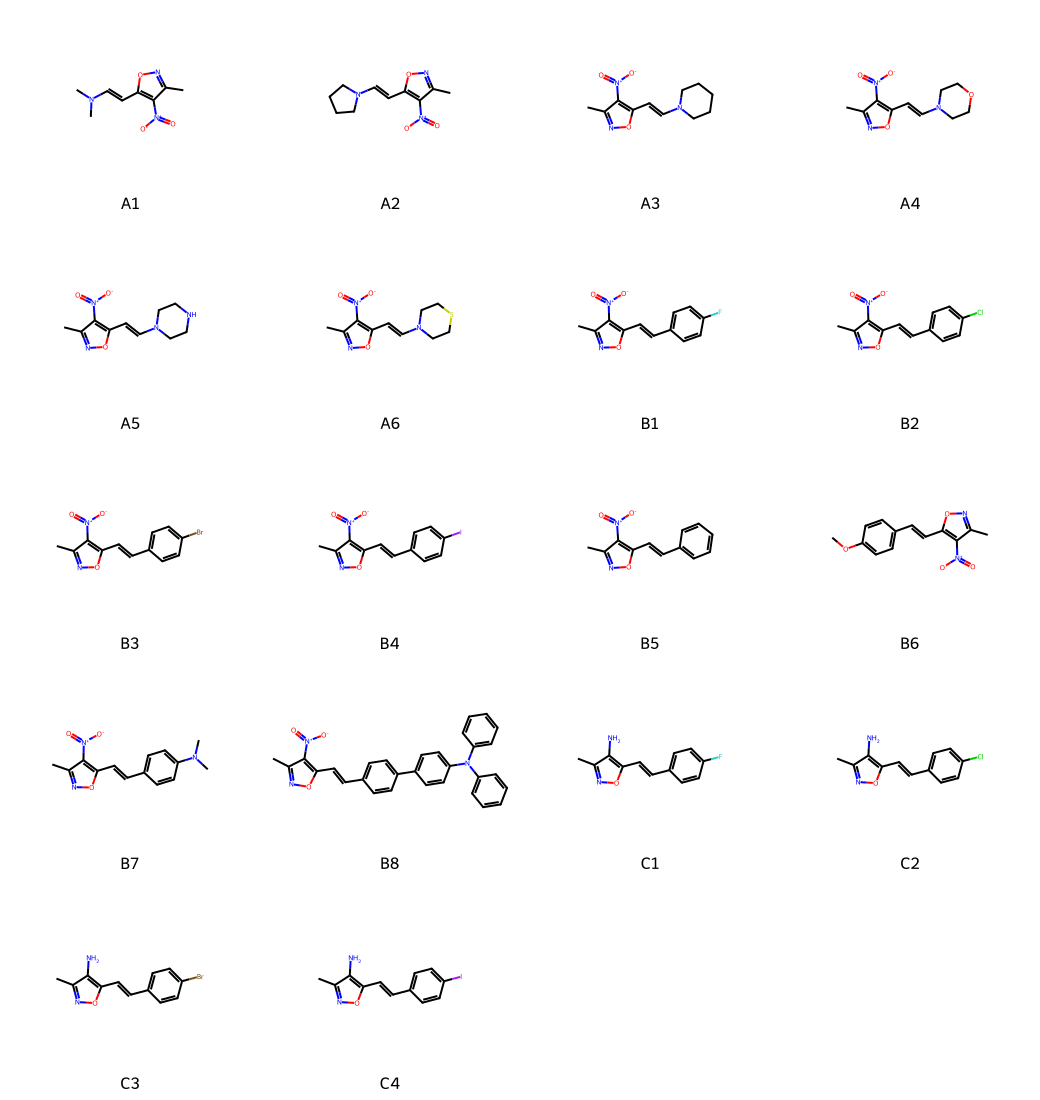

,compound_id,series,r_group,valid_smiles,mw,logp,tpsa,hbd,hba,rotatable_bonds,lipinski_violations,lipinski_pass
0,A1,A,N(CH3)2,True,197.194,1.424,72.41,0,5,3,0,True
1,A2,A,pyrrolidine,True,223.232,1.958,72.41,0,5,3,0,True
2,A3,A,piperidine,True,237.259,2.348,72.41,0,5,3,0,True
3,A4,A,morpholine,True,239.231,1.194,81.64,0,6,3,0,True
4,A5,A,piperazine,True,238.247,0.767,84.44,1,6,3,0,True
5,A6,A,thiomorpholine,True,255.299,1.911,72.41,0,6,3,0,True
6,B1,B,4-F,True,248.213,3.201,69.17,0,4,3,0,True
7,B2,B,4-Cl,True,264.668,3.715,69.17,0,4,3,0,True
8,B3,B,4-Br,True,309.119,3.824,69.17,0,4,3,0,True
9,B4,B,4-I,True,356.119,3.666,69.17,0,4,3,0,True


In [4]:
display(Image(filename=str(STRUCTURE_FIGURE)))
pd.read_csv(TRIAGE_OUTPUT)[['compound_id','series','r_group','valid_smiles','mw','logp','tpsa','hbd','hba','rotatable_bonds','lipinski_violations','lipinski_pass']]


## 4. Completar plantilla alvaDesc/WEKA

Completa `data/query/candidate_compounds_alvadesc_11_template.csv` con los 11 descriptores y luego ejecuta la validacion/prediccion.


In [5]:
template = pd.read_csv(ALVADESC_TEMPLATE)
template


,compound_id,preliminary_smiles,LOGPcons,MACCSFP125,PCR,Psi_e_A,P_VSA_ppp_D,Mp,SpMin1_Bh(p),SHED_AL,SM12_AEA(ri),P_VSA_s_3,MATS5m
0,A1,CN(C)/C=C/c1onc(C)c([N+](=O)[O-])1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A2,C1CCN(/C=C/c2onc(C)c([N+](=O)[O-])2)C1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A3,C1CCN(/C=C/c2onc(C)c([N+](=O)[O-])2)CC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A4,C1COCCN1/C=C/c2onc(C)c([N+](=O)[O-])2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A5,C1CNCCN1/C=C/c2onc(C)c([N+](=O)[O-])2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,A6,C1CSCCN1/C=C/c2onc(C)c([N+](=O)[O-])2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,B1,Cc1noc(/C=C/c2ccc(F)cc2)c1[N+](=O)[O-],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,B2,Cc1noc(/C=C/c2ccc(Cl)cc2)c1[N+](=O)[O-],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,B3,Cc1noc(/C=C/c2ccc(Br)cc2)c1[N+](=O)[O-],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,B4,Cc1noc(/C=C/c2ccc(I)cc2)c1[N+](=O)[O-],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4b. Importar exports de alvaDesc

Si ya calculaste `descriptores0-2D.txt` y `MACCS166.txt` en alvaDesc, ejecuta esta celda.
El notebook fusiona ambos archivos, extrae los 11 descriptores del modelo de tesis y actualiza la plantilla usada por el modelo.

Supuesto importante: el orden de alvaDesc debe ser A1-A6, B1-B8, C1-C4.


In [6]:
ALVADESC_2D_EXPORT = Path.home() / 'Downloads' / 'descriptores0-2D.txt'
ALVADESC_MACCS_EXPORT = Path.home() / 'Downloads' / 'MACCS166.txt'
MERGE_REPORT = Path('results/screening/candidate_compounds_alvadesc_merge_report.json')
MERGED_FULL_EXPORT = Path('data/query/candidate_compounds_alvadesc_merged_full.csv')

if not ALVADESC_2D_EXPORT.exists() or not ALVADESC_MACCS_EXPORT.exists():
    display(Markdown(f'**No encontre los exports de alvaDesc.** Revisa estas rutas: `{ALVADESC_2D_EXPORT}` y `{ALVADESC_MACCS_EXPORT}`.'))
else:
    !python src/merge_alvadesc_exports.py --descriptors $ALVADESC_2D_EXPORT --maccs $ALVADESC_MACCS_EXPORT --output $ALVADESC_TEMPLATE --merged-output $MERGED_FULL_EXPORT --report $MERGE_REPORT
    display(pd.read_csv(ALVADESC_TEMPLATE))


{
  "records": 18,
  "descriptor_source": "C:\\Users\\benja\\Downloads\\descriptores0-2D.txt",
  "maccs_source": "C:\\Users\\benja\\Downloads\\MACCS166.txt",
  "output": "data\\query\\candidate_compounds_alvadesc_11_template.csv",
  "merged_output": "data\\query\\candidate_compounds_alvadesc_merged_full.csv",
  "compound_id_mapping": "default_A1-A6_B1-B8_C1-C4_order",
  "required_descriptors": [
    "LOGPcons",
    "MACCSFP125",
    "PCR",
    "Psi_e_A",
    "P_VSA_ppp_D",
    "Mp",
    "SpMin1_Bh(p)",
    "SHED_AL",
    "SM12_AEA(ri)",
    "P_VSA_s_3",
    "MATS5m"
  ],
  "missing_descriptors": []
}


,compound_id,alvadesc_name,LOGPcons,MACCSFP125,PCR,Psi_e_A,P_VSA_ppp_D,Mp,SpMin1_Bh(p),SHED_AL,SM12_AEA(ri),P_VSA_s_3,MATS5m
0,A1,Molecule1,1.111555,0,1.307664,8.321429,0.000000,0.617048,1.985841,3.618492,3.048352,10.962316,-0.191396
1,A2,Molecule2,1.650153,0,1.293976,8.093750,0.000000,0.627159,1.983261,5.937163,3.053143,20.242788,-0.153380
2,A3,Molecule3,2.029409,0,1.287311,8.029412,0.000000,0.623406,2.027091,6.667308,3.052680,22.777320,0.001891
3,A4,Molecule4,0.884808,0,1.287311,8.147059,0.000000,0.621403,2.004762,5.010182,3.052680,24.358494,0.050795
4,A5,Molecule5,0.653708,0,1.287311,8.088235,18.010751,0.619139,2.018443,3.618492,3.052680,19.385133,0.024686
5,A6,Molecule6,1.624953,0,1.287311,8.049020,0.000000,0.661177,1.992244,6.038197,3.052680,49.192647,0.041246
6,B1,Molecule7,3.135344,1,1.468766,8.435185,0.000000,0.679926,2.014543,6.509991,3.649544,23.268909,-0.139288
7,B2,Molecule8,3.504684,1,1.468766,8.219136,0.000000,0.714015,2.006854,7.969602,3.649544,17.648498,-0.047265
8,B3,Molecule9,3.613304,1,1.468766,8.143519,0.000000,0.732326,2.004878,7.969602,3.649544,17.202995,0.022803
9,B4,Molecule10,3.547540,1,1.468766,8.108519,0.000000,0.780726,2.002056,7.969602,3.649544,15.807534,0.028272


## 5. Validar e inyectar al modelo PAMPA


In [7]:
descriptor_table = pd.read_csv(ALVADESC_TEMPLATE)
missing_or_empty = []
for col in THESIS_DESCRIPTORS:
    if col not in descriptor_table.columns or descriptor_table[col].isna().any() or (descriptor_table[col].astype(str).str.strip() == '').any():
        missing_or_empty.append(col)
validation_status = {'ready_for_model': len(missing_or_empty) == 0, 'missing_or_empty_descriptors': missing_or_empty, 'rows': len(descriptor_table)}
validation_status


{'ready_for_model': True, 'missing_or_empty_descriptors': [], 'rows': 18}

In [8]:
PREDICTIONS_OUTPUT = Path('results/agentic/candidate_compounds_predictions.csv')
PREDICTIONS_JSON = Path('results/agentic/candidate_compounds_report.json')
PREDICTIONS_MD = Path('results/agentic/candidate_compounds_report.md')
if not validation_status['ready_for_model']:
    display(Markdown('**Aun no se puede predecir.** Completa primero los 11 descriptores en la plantilla alvaDesc/WEKA.'))
    display(validation_status)
else:
    !python src/agentic/local_orchestrator.py --input $ALVADESC_TEMPLATE --output $PREDICTIONS_OUTPUT --report-json $PREDICTIONS_JSON --report-md $PREDICTIONS_MD --id-column compound_id
    display(pd.read_csv(PREDICTIONS_OUTPUT))


{
  "workflow": "local_no_api_agent_panel",
  "api_required": false,
  "row_count": 18,
  "agents": [
    {
      "agent": "DescriptorAgent",
      "status": "pass",
      "warnings": []
    },
    {
      "agent": "ChemicalAgent",
      "status": "not_applicable",
      "warnings": [
        "No SMILES column was provided; chemical structure checks were skipped."
      ]
    },
    {
      "agent": "ModelAgent",
      "status": "pass",
      "warnings": []
    },
    {
      "agent": "ApplicabilityDomainAgent",
      "status": "pass",
      "warnings": []
    },
    {
      "agent": "PhysicsAgent",
      "status": "pass",
      "warnings": []
    }
  ],
  "approved_predictions": 18,
  "predicted_permeable": 12,
  "predicted_non_permeable": 6
}


,compound_id,probability_permeable,predicted_label,predicted_class,model_id,descriptor_contract,approved_for_decision,leverage,h_star,in_domain,physics_interpretation,physics_comments,local_agent_decision
0,A1,0.064424,0,NO_PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.002327,0.008263,True,non_permeability_signal,Low LOGPcons may limit passive membrane partit...,LOW_PRIORITY_OR_NON_PERMEABLE
1,A2,0.325332,0,NO_PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.001831,0.008263,True,non_permeability_signal,Low LOGPcons may limit passive membrane partit...,LOW_PRIORITY_OR_NON_PERMEABLE
2,A3,0.299448,0,NO_PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.001486,0.008263,True,non_permeability_signal,NaN,LOW_PRIORITY_OR_NON_PERMEABLE
3,A4,0.144152,0,NO_PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.001948,0.008263,True,non_permeability_signal,Low LOGPcons may limit passive membrane partit...,LOW_PRIORITY_OR_NON_PERMEABLE
4,A5,0.128362,0,NO_PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.001814,0.008263,True,non_permeability_signal,Low LOGPcons may limit passive membrane partit...,LOW_PRIORITY_OR_NON_PERMEABLE
5,A6,0.393005,0,NO_PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.001949,0.008263,True,non_permeability_signal,Low LOGPcons may limit passive membrane partit...,LOW_PRIORITY_OR_NON_PERMEABLE
6,B1,0.654096,1,PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.001598,0.008263,True,borderline_permeability_signal,High LOGPcons supports passive membrane partit...,CANDIDATE_PERMEABLE
7,B2,0.647147,1,PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.001056,0.008263,True,borderline_permeability_signal,High LOGPcons supports passive membrane partit...,CANDIDATE_PERMEABLE
8,B3,0.664816,1,PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.001057,0.008263,True,borderline_permeability_signal,High LOGPcons supports passive membrane partit...,CANDIDATE_PERMEABLE
9,B4,0.655340,1,PERMEABLE,thesis_rf_11_alvadesc_weka,thesis_11_descriptors_v1,True,0.001463,0.008263,True,borderline_permeability_signal,High LOGPcons supports passive membrane partit...,CANDIDATE_PERMEABLE


## 6. Graficos de comportamiento

Estos graficos resumen como se comportan las series A/B/C frente al modelo PAMPA.
La linea punteada marca el umbral de decision `0.5`: sobre esa linea el modelo clasifica como permeable.


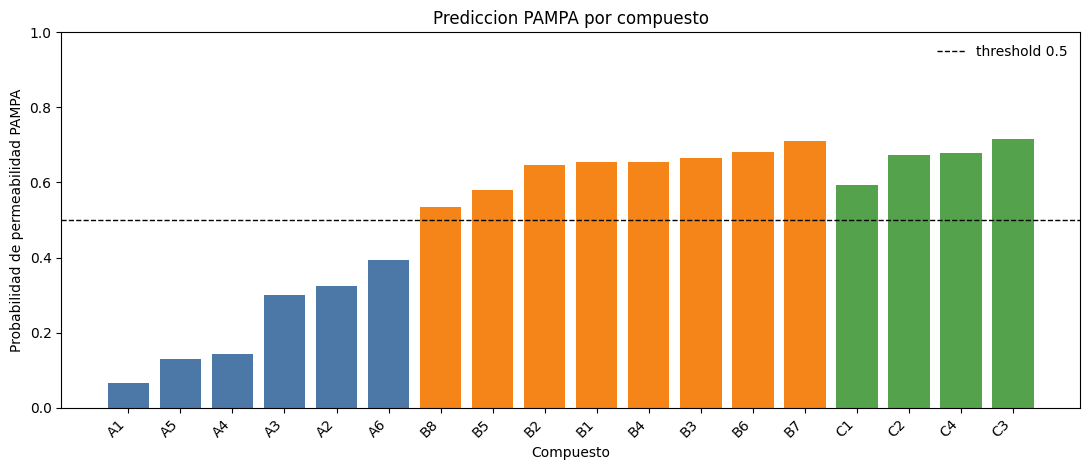

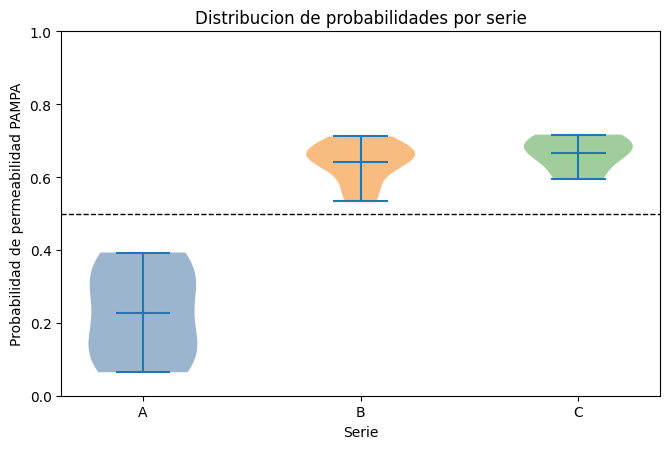

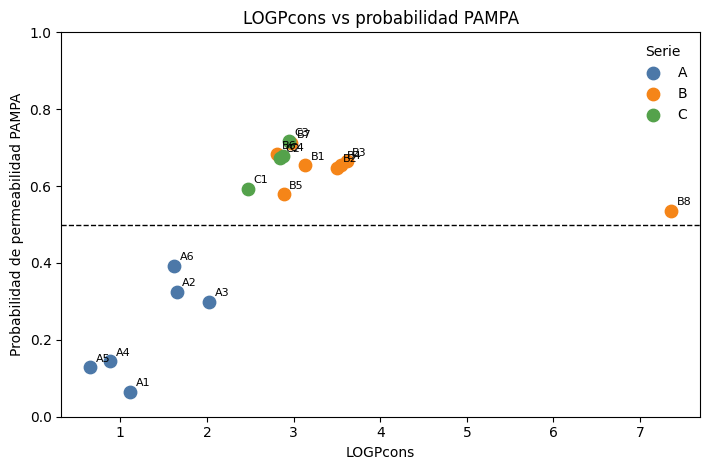

Archivos generados:

,grafico,ruta
0,barras_probabilidad,results\figures\candidate_compounds_probabilit...
1,distribucion_por_serie,results\figures\candidate_compounds_series_dis...
2,logp_vs_probabilidad,results\figures\candidate_compounds_logp_proba...


,compound_id,series,probability_permeable,predicted_class,LOGPcons
0,A1,A,0.064424,NO_PERMEABLE,1.111555
1,A5,A,0.128362,NO_PERMEABLE,0.653708
2,A4,A,0.144152,NO_PERMEABLE,0.884808
3,A3,A,0.299448,NO_PERMEABLE,2.029409
4,A2,A,0.325332,NO_PERMEABLE,1.650153
5,A6,A,0.393005,NO_PERMEABLE,1.624953
6,B8,B,0.535074,PERMEABLE,7.355952
7,B5,B,0.579244,PERMEABLE,2.885479
8,B2,B,0.647147,PERMEABLE,3.504684
9,B1,B,0.654096,PERMEABLE,3.135344


In [9]:
import matplotlib.pyplot as plt
import numpy as np

PREDICTIONS_OUTPUT = Path('results/agentic/candidate_compounds_predictions.csv')
if not PREDICTIONS_OUTPUT.exists():
    alt = Path('results/agentic/candidate_compounds_alvadesc_predictions.csv')
    if alt.exists():
        PREDICTIONS_OUTPUT = alt

if not PREDICTIONS_OUTPUT.exists():
    display(Markdown('**Primero ejecuta la prediccion del modelo.** No encontre el archivo de resultados.'))
else:
    predictions = pd.read_csv(PREDICTIONS_OUTPUT)
    descriptors = pd.read_csv(ALVADESC_TEMPLATE) if ALVADESC_TEMPLATE.exists() else pd.DataFrame()
    triage = pd.read_csv(TRIAGE_OUTPUT) if TRIAGE_OUTPUT.exists() else pd.DataFrame()
    plot_df = predictions.copy()
    if 'compound_id' in plot_df.columns:
        plot_df['series'] = plot_df['compound_id'].astype(str).str.extract(r'^([A-Za-z]+)')
    if not descriptors.empty and 'compound_id' in descriptors.columns:
        keep = ['compound_id'] + [c for c in ['LOGPcons', 'Mp', 'P_VSA_s_3', 'SHED_AL'] if c in descriptors.columns]
        plot_df = plot_df.merge(descriptors[keep], on='compound_id', how='left')
    if not triage.empty and 'compound_id' in triage.columns:
        keep = ['compound_id'] + [c for c in ['mw', 'logp', 'tpsa', 'lipinski_pass'] if c in triage.columns]
        plot_df = plot_df.merge(triage[keep], on='compound_id', how='left')

    fig_dir = Path('results/figures')
    fig_dir.mkdir(parents=True, exist_ok=True)
    colors = {'A': '#4C78A8', 'B': '#F58518', 'C': '#54A24B'}
    plot_df = plot_df.sort_values(['series', 'probability_permeable']).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(11, 4.8))
    bar_colors = [colors.get(str(s), '#777777') for s in plot_df['series']]
    ax.bar(plot_df['compound_id'], plot_df['probability_permeable'], color=bar_colors)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='threshold 0.5')
    ax.set_ylabel('Probabilidad de permeabilidad PAMPA')
    ax.set_xlabel('Compuesto')
    ax.set_ylim(0, 1)
    ax.set_title('Prediccion PAMPA por compuesto')
    ax.legend(frameon=False)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    bar_path = fig_dir / 'candidate_compounds_probability_bars.png'
    fig.savefig(bar_path, dpi=200)
    plt.show()

    fig, ax = plt.subplots(figsize=(6.8, 4.6))
    data_by_series = [g['probability_permeable'].values for _, g in plot_df.groupby('series')]
    labels = [str(k) for k, _ in plot_df.groupby('series')]
    parts = ax.violinplot(data_by_series, showmeans=True, showextrema=True)
    for body, label in zip(parts['bodies'], labels):
        body.set_facecolor(colors.get(label, '#777777'))
        body.set_alpha(0.55)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(range(1, len(labels) + 1), labels)
    ax.set_ylabel('Probabilidad de permeabilidad PAMPA')
    ax.set_xlabel('Serie')
    ax.set_ylim(0, 1)
    ax.set_title('Distribucion de probabilidades por serie')
    plt.tight_layout()
    violin_path = fig_dir / 'candidate_compounds_series_distribution.png'
    fig.savefig(violin_path, dpi=200)
    plt.show()

    x_col = 'LOGPcons' if 'LOGPcons' in plot_df.columns else ('logp' if 'logp' in plot_df.columns else None)
    if x_col:
        fig, ax = plt.subplots(figsize=(7.2, 4.8))
        for series, group in plot_df.groupby('series'):
            ax.scatter(group[x_col], group['probability_permeable'], s=80, color=colors.get(str(series), '#777777'), label=series)
            for _, row in group.iterrows():
                ax.annotate(row['compound_id'], (row[x_col], row['probability_permeable']), xytext=(4, 4), textcoords='offset points', fontsize=8)
        ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
        ax.set_xlabel(x_col)
        ax.set_ylabel('Probabilidad de permeabilidad PAMPA')
        ax.set_ylim(0, 1)
        ax.set_title(f'{x_col} vs probabilidad PAMPA')
        ax.legend(title='Serie', frameon=False)
        plt.tight_layout()
        scatter_path = fig_dir / 'candidate_compounds_logp_probability_scatter.png'
        fig.savefig(scatter_path, dpi=200)
        plt.show()

    display(Markdown('Archivos generados:'))
    display(pd.DataFrame([
        {'grafico': 'barras_probabilidad', 'ruta': str(bar_path)},
        {'grafico': 'distribucion_por_serie', 'ruta': str(violin_path)},
        {'grafico': 'logp_vs_probabilidad', 'ruta': str(scatter_path) if x_col else 'no generado'},
    ]))
    display(plot_df[['compound_id', 'series', 'probability_permeable', 'predicted_class'] + ([x_col] if x_col else [])])
